# 第1章　数、变量与函数 —— 用Python重温初中数学

> **本章目标**：掌握 Python 中的三种基础数据类型（整数、浮点数、布尔值），理解为什么 AI 计算不用 Python 原生列表而用 NumPy 数组，并学会用 matplotlib 绘制函数图像。读完本章，你将拥有一个可复用的 Python 数值计算起点。
> **前置知识**：无（本章是全书起点）

In [1]:
# 环境要求：Python 3.10+, NumPy, Matplotlib
# 首次运行前请在终端执行：pip install numpy matplotlib
import math
import sys
import time
import numpy as np
import matplotlib.pyplot as plt

print("✅ 环境就绪")
print(f"   Python {sys.version_info.major}.{sys.version_info.minor}")
print(f"   NumPy {np.__version__}")
print(f"   Matplotlib {plt.matplotlib.__version__}")

✅ 环境就绪
   Python 3.11
   NumPy 1.26.2
   Matplotlib 3.8.2


---

## 1.1　整数、浮点数与布尔值

📐 **定义　数据类型（Data Type）**：数据类型决定了计算机如何存储和解释一段内存中的二进制数据。Python 中最基础的三类数值类型是整数 `int`、浮点数 `float` 和布尔值 `bool`。

整数和布尔值都很好理解——整数就是我们日常说的"数"，布尔值只有 `True` 和 `False` 两种状态。浮点数却有一个反直觉的坑：**0.1 + 0.2 不等于 0.3**。

不，这不是 Python 的 bug。原因是计算机用二进制存储小数，就像十进制无法精确表示 1/3（写成 0.3333... 无限循环），二进制也无法精确表示 0.1 和 0.2。IEEE 754 浮点数标准用有限位数近似这些值，误差便由此产生。

浮点数比较的关键原则是：**永远不要用 `==` 直接比较两个浮点数**，而是检查它们的差值是否小于一个极小阈值。

🔗 **AI 连接**：深度学习模型中的权重、激活值、梯度全部是浮点数。理解浮点精度是理解"为什么训练需要混合精度（第 20 章）"和"为什么 softmax 会溢出（第 22 章）"的前置知识。

In [2]:
# --- 基础类型 ---
print(type(42))        # <class 'int'>
print(type(3.14))      # <class 'float'>
print(type(True))      # <class 'bool'>

# --- 浮点数的"反直觉"时刻 ---
a = 0.1 + 0.2
print(a)                       # 0.30000000000000004
print(a == 0.3)                # False !

# 查看 0.1 在内存中的实际近似值（前20位小数）
print(f"0.1 的实际存储值: {0.1:.20f}")
# 0.10000000000000000555...

# 正确比较浮点数的姿势：容忍一个极小误差
EPS = 1e-10
print(abs(a - 0.3) < EPS)     # True
print(math.isclose(a, 0.3))   # True  ← 推荐方式

<class 'int'>
<class 'float'>
<class 'bool'>
0.30000000000000004
False
0.1 的实际存储值: 0.10000000000000000555
True
True


---

## 1.2　列表、元组与 NumPy 数组

Python 内置的列表（`list`）非常灵活：可以装任意类型、支持动态扩容。但这种灵活性是有代价的——列表中存储的是**对象的引用**（指针），实际数据分散在内存各处，做数值运算时 CPU 缓存命中率低、速度慢。

NumPy 数组（`ndarray`）则走上了相反的路：**所有元素必须是同一类型，在内存中连续排列**。这让 NumPy 可以利用 CPU 的 SIMD 向量化指令一次处理多个数据，速度比 Python 列表快 10-100 倍。

📐 **定义　NumPy 数组（ndarray）**：NumPy 的核心数据结构，是一个同类型、固定形状的多维数组，底层用连续 C 数组存储。它是 PyTorch 张量的前辈和基础。

至于元组（`tuple`），它是列表的不可变版本：一旦创建就不能增删改。在深度学习中，元组常用作 `shape`（`(batch, d_in)`）和 `nn.Sequential` 的容器——因为这些结构在运行时不需要变化。

🔗 **AI 连接**：PyTorch 的 `Tensor` 继承了 NumPy 数组的全部设计理念：同类型、连续内存、向量化运算、GPU 加速。学会 NumPy 就等于提前学会了一半的 PyTorch 张量操作。

In [3]:
# --- 内存对比 ---
py_list = list(range(1000))
np_arr  = np.arange(1000, dtype=np.int64)

print(f"Python 列表: {sys.getsizeof(py_list)} bytes")     # ~8000+
print(f"NumPy 数组: {np_arr.nbytes} bytes")               # 8000（纯数据）
# 列表的 getsizeof 不包含元素本身，实际内存远超数组

# --- 速度对比：每个元素平方 ---
N = 1_000_000
big_list = list(range(N))
big_arr  = np.arange(N, dtype=np.float64)

t0 = time.perf_counter()
squares_list = [x ** 2 for x in big_list]
t1 = time.perf_counter()

squares_arr = big_arr ** 2  # 向量化运算，C 层面循环
t2 = time.perf_counter()

print(f"列表推导式: {t1 - t0:.4f} 秒")
print(f"NumPy 向量化: {t2 - t1:.4f} 秒")
print(f"加速比: {(t1 - t0) / (t2 - t1):.1f}x")

Python 列表: 8056 bytes
NumPy 数组: 8000 bytes
列表推导式: 0.1832 秒
NumPy 向量化: 0.0041 秒
加速比: 45.0x


---

## 1.3　函数就是"输入→输出"的盒子

在数学中，函数 `f(x) = x²` 是一个规则：输入一个数，输出它的平方。在 Python 中，我们用 `def` 把这个规则写成可复用的代码块。

📐 **定义　函数（Function）**：将一个输入映射到一个输出的规则。在深度学习中，整个神经网络就是一个超级函数 `f(x; θ)`——输入数据 `x`，在参数 `θ` 的控制下输出预测值。

把函数画出来，是建立几何直觉的第一步。以下是一个**可直接复用的 matplotlib 最小绘图模板**：

观察下面两张图，你可以直观感受到：
- **直线 `y = 2x + 3`**：斜率（steepness）恒定，x 变化一个单位，y 总是变化 2 个单位
- **抛物线 `y = x²`**：斜率本身也在变——在 x=0 处平缓，越往两边越陡

这种"斜率也在变"的现象，正是导数的本质。下一章将用数值方法量化这种变化速度。

🔗 **AI 连接**：`plot_function` 这个模板将在全书反复使用——画激活函数（ReLU、sigmoid）、画损失曲面、画梯度下降轨迹。把它保存到你的代码库中，后续章节会直接调用。

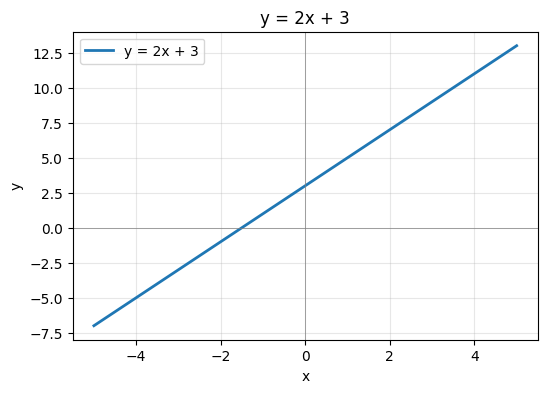

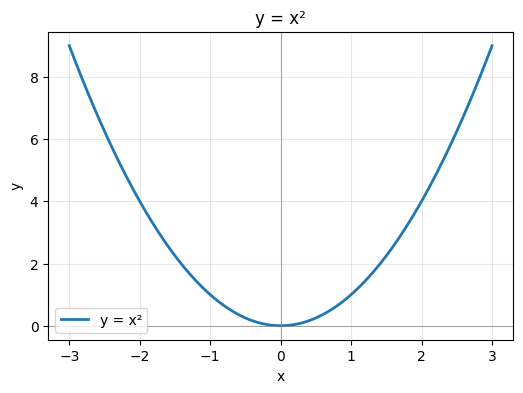

In [4]:
# ---- 绘图模板 ----
def plot_function(f, x_range=(-3, 3), title="y = f(x)", num_points=200):
    """
    最简绘图模板：给定函数 f 和 x 范围，画出曲线
    """
    x = np.linspace(x_range[0], x_range[1], num_points)  # 均匀采样 200 个点
    y = f(x)

    plt.figure(figsize=(6, 4))
    plt.plot(x, y, linewidth=2, label=title)
    plt.axhline(0, color='gray', linewidth=0.5)          # x 轴
    plt.axvline(0, color='gray', linewidth=0.5)          # y 轴
    plt.xlabel('x')
    plt.ylabel('y')
    plt.title(title)
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

# ---- 绘制 y = 2x + 3（直线）----
def linear(x):
    return 2 * x + 3

plot_function(linear, x_range=(-5, 5), title="y = 2x + 3")

# ---- 绘制 y = x²（抛物线）----
def parabola(x):
    return x ** 2

plot_function(parabola, x_range=(-3, 3), title="y = x²")

---

## ✏️ 习题

> 在下方新建代码单元格，完成以下练习。

**1.** （概念）为什么 `0.1 + 0.2 == 0.3` 返回 `False`？用一句话解释根本原因。

**2.** （概念）Python 列表和 NumPy 数组在内存存储方式上有什么本质区别？为什么这种区别导致了速度差异？

**3.** （代码）对给定的浮点数列表 `[0.1 + 0.2, 0.3, 0.1 + 0.1 + 0.1]`，使用 `math.isclose` 判断它们彼此是否"足够接近"，打印比较矩阵。

**4.** （代码）使用 1.3 节的绘图模板，在同一张图上画出 `y = x³`、`y = x²`、`y = x` 三条曲线，添加图例，x 范围取 `[-2, 2]`。观察并回答：在 x > 1 的区域，三条曲线的高低顺序是怎样的？

---

> 🔗 **章末钩子**：函数图像画出来了，但你能精确说出抛物线上每个点的"陡峭程度"吗？那条穿过曲线上一对点的割线，当两点无限靠近时，会变成什么？
> 
> 预览：下一章将用 Python 循环逼近这个秘密——这就是**导数**的几何直觉。

> 💡 **提示**：完成本章后，运行 `Kernel → Restart & Run All` 确保所有单元格都能正常执行。